# Preprocessed Frame Check

Pick one random `.npy` file from `data/processed`, visualize it, and run a few basic sanity checks.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd()
processed_dir = cwd / "data" / "processed"
if not processed_dir.exists():
    processed_dir = cwd.parent / "data" / "processed"

files = sorted(processed_dir.glob("*.npy"))
assert files, f"No .npy files found in {processed_dir.resolve()}"

print(f"Found {len(files)} preprocessed files in {processed_dir.resolve()}")

Found 1152 preprocessed files in /home/imaayush/code/cloudDiffusion/data/processed


In [2]:
rng = np.random.default_rng()
sample_path = rng.choice(files)
frame = np.load(sample_path)

stats = {
    "file": sample_path.name,
    "shape": frame.shape,
    "dtype": str(frame.dtype),
    "min": float(frame.min()),
    "max": float(frame.max()),
    "mean": float(frame.mean()),
    "std": float(frame.std()),
    "finite_fraction": float(np.isfinite(frame).mean()),
    "zero_fraction": float((frame == 0).mean()),
}

for key, value in stats.items():
    print(f"{key}: {value}")

assert frame.ndim == 2, f"Expected a 2D frame, got shape {frame.shape}"
assert frame.size > 0, "Frame is empty"
assert np.isfinite(frame).all(), "Frame contains NaN or inf values"
assert frame.min() >= 0.0, f"Frame min is below 0: {frame.min()}"
assert frame.max() <= 1.0, f"Frame max is above 1: {frame.max()}"
assert frame.std() > 0.0, "Frame has no variation"

print("Sanity checks passed.")

file: OR_ABI-L1b-RadC-M6C13_G16_s20231831526181_e20231831528565_c20231831529020.npy
shape: (256, 256)
dtype: float32
min: 0.445327490568161
max: 0.8849542737007141
mean: 0.7976384162902832
std: 0.07705972343683243
finite_fraction: 1.0
zero_fraction: 0.0
Sanity checks passed.


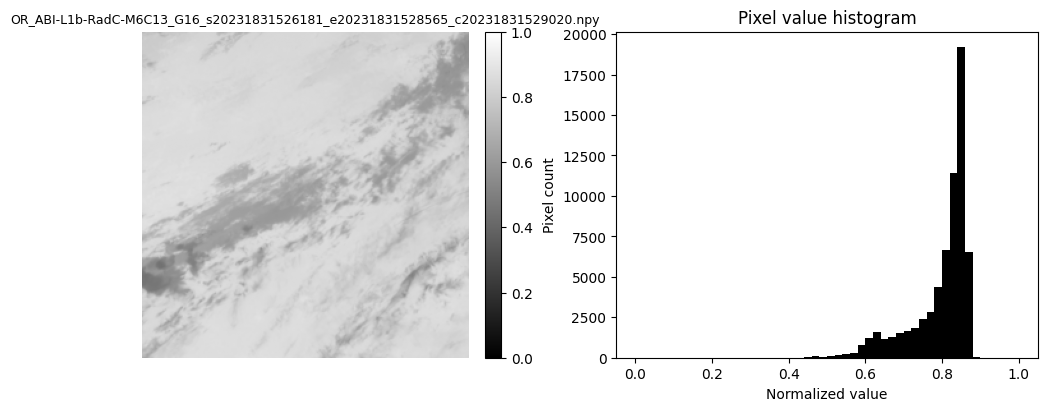

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

image = axes[0].imshow(frame, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(sample_path.name, fontsize=9)
axes[0].axis("off")
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].hist(frame.ravel(), bins=50, range=(0, 1), color="black")
axes[1].set_title("Pixel value histogram")
axes[1].set_xlabel("Normalized value")
axes[1].set_ylabel("Pixel count")

plt.show()

In [4]:
import sys
sys.path.insert(0, str(Path.cwd().parent if not (Path.cwd() / "src").exists() else Path.cwd()))
import torch
from torch.utils.data import DataLoader
from src.dataset import Clouds

manifest_path = cwd / "data" / "manifest.json"
if not manifest_path.exists():
    manifest_path = cwd.parent / "data" / "manifest.json"

ds = Clouds(manifest_path=str(manifest_path), T=6)
loader = DataLoader(ds, batch_size=4, shuffle=True, num_workers=0)
inputs, target = next(iter(loader))

print(f"Dataset size:       {len(ds)} sequences")
print(f"inputs shape:       {inputs.shape}  (batch, T, H, W)")
print(f"target shape:       {target.shape}  (batch, H, W)")
print(f"inputs dtype:       {inputs.dtype}")
print(f"inputs min/max:     {inputs.min():.4f} / {inputs.max():.4f}")
print(f"target min/max:     {target.min():.4f} / {target.max():.4f}")

assert inputs.shape[1] == 6, f"Expected T=6 input frames, got {inputs.shape[1]}"
assert inputs.shape[2:] == target.shape[1:], "Input and target spatial dims do not match"
assert inputs.min() >= 0.0 and inputs.max() <= 1.0, "inputs outside [0, 1]"
assert target.min() >= 0.0 and target.max() <= 1.0, "target outside [0, 1]"

print("Dataset checks passed.")

Dataset size:       1146 sequences
inputs shape:       torch.Size([4, 6, 256, 256])  (batch, T, H, W)
target shape:       torch.Size([4, 256, 256])  (batch, H, W)
inputs dtype:       torch.float32
inputs min/max:     0.2302 / 0.9219
target min/max:     0.2495 / 0.9230
Dataset checks passed.


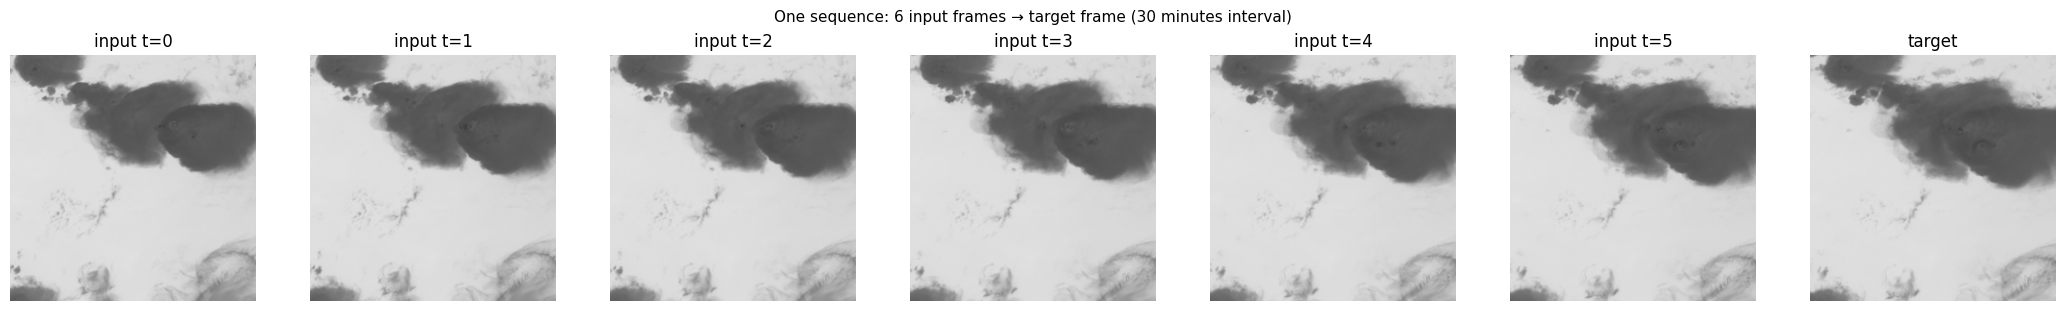

In [5]:
seq_inputs, seq_target = ds[0]

n = seq_inputs.shape[0]
fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 3), constrained_layout=True)

for t in range(n):
    axes[t].imshow(seq_inputs[t].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[t].set_title(f"input t={t}")
    axes[t].axis("off")

axes[-1].imshow(seq_target.numpy(), cmap="gray", vmin=0, vmax=1)
axes[-1].set_title("target")
axes[-1].axis("off")

plt.suptitle("One sequence: 6 input frames → target frame (30 minutes interval)", fontsize=11)
plt.show()